# IEEE Fraud Detection EDA

This notebook explores the interim IEEE fraud-detection data stored as parquet files in `data/interim/ieee-fraud-detection`.

The goal is to understand the structure of the transaction and identity tables, identify data quality and predictive patterns, and build a lightweight baseline for predicting `isFraud`.

We focus on:

- target imbalance and dataset coverage
- missingness and schema consistency
- fraud patterns in key transaction, categorical, and identity features
- time-based transaction behavior from `TransactionDT`
- a simple, chronological validation baseline for fraud prediction


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data/interim/ieee-fraud-detection")
RANDOM_STATE = 42


def top_missing(df, name, n=20):
    missing = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .head(n)
        .rename("missing_rate")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    missing["dataset"] = name
    return missing


def fraud_rate_table(df, feature, top_n=10):
    temp = df[[feature, "isFraud"]].copy()
    counts = temp[feature].value_counts(dropna=False)
    keep = counts.head(top_n).index
    temp[feature] = temp[feature].where(temp[feature].isin(keep), "Other")
    summary = (
        temp.groupby(feature, dropna=False)
        .agg(transactions=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
        .sort_values("fraud_rate", ascending=False)
    )
    return summary


def plot_fraud_rate(summary, title, xlabel):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ordered = summary.sort_values("fraud_rate", ascending=False)
    sns.barplot(
        data=ordered.reset_index(),
        x=ordered.index.name or "index",
        y="fraud_rate",
        color="#d95f02",
        ax=ax1,
    )
    ax1.set_title(title)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Fraud rate")
    ax1.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


In [2]:
train_transaction = pd.read_parquet(DATA_DIR / "train_transaction.parquet")
train_identity = pd.read_parquet(DATA_DIR / "train_identity.parquet")
test_transaction = pd.read_parquet(DATA_DIR / "test_transaction.parquet")
test_identity = pd.read_parquet(DATA_DIR / "test_identity.parquet")

overview = pd.DataFrame(
    {
        "rows": [
            len(train_transaction),
            len(train_identity),
            len(test_transaction),
            len(test_identity),
        ],
        "columns": [
            train_transaction.shape[1],
            train_identity.shape[1],
            test_transaction.shape[1],
            test_identity.shape[1],
        ],
    },
    index=[
        "train_transaction",
        "train_identity",
        "test_transaction",
        "test_identity",
    ],
)

display(overview)

schema_check = pd.DataFrame(
    {
        "train_identity_columns": train_identity.columns.astype(str),
        "test_identity_columns": test_identity.columns.astype(str),
    }
)
display(schema_check.head(12))


,rows,columns
train_transaction,590540,394
train_identity,144233,41
test_transaction,506691,393
test_identity,141907,41


,train_identity_columns,test_identity_columns
0,TransactionID,TransactionID
1,id_01,id-01
2,id_02,id-02
3,id_03,id-03
4,id_04,id-04
5,id_05,id-05
6,id_06,id-06
7,id_07,id-07
8,id_08,id-08
9,id_09,id-09


Fraud rate in training transactions: 3.50%
Transactions with identity information: 24.42%


,metric,value
0,train fraud rate,0.0350
1,non-fraud transactions,"569,877.0000"
2,fraud transactions,"20,663.0000"
3,identity coverage on train,0.2442
4,train_transaction memory (MB),"2,076.2552"
5,train_identity memory (MB),153.4168


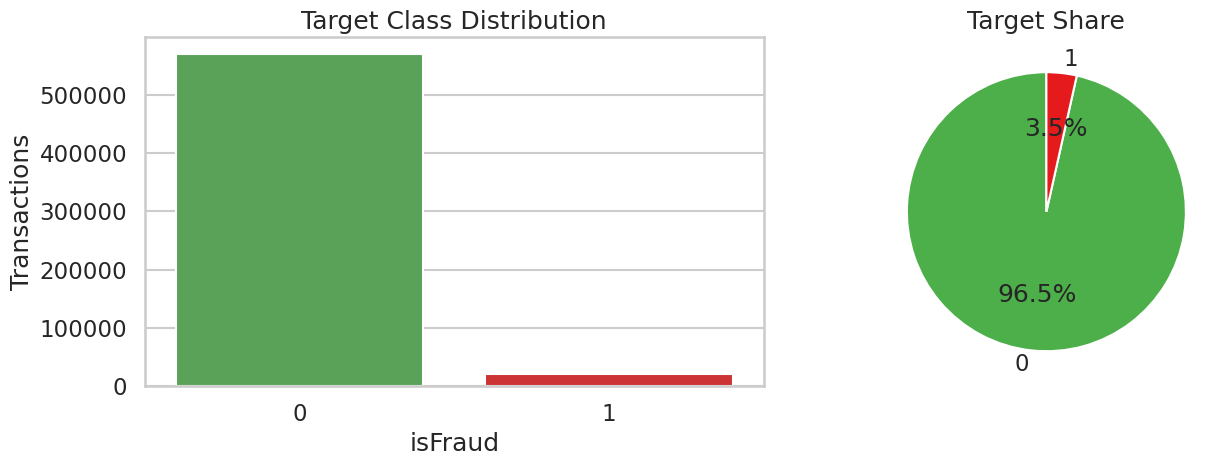

In [3]:
target_rate = train_transaction["isFraud"].mean()
target_counts = train_transaction["isFraud"].value_counts().sort_index()
identity_coverage = train_identity["TransactionID"].nunique() / train_transaction["TransactionID"].nunique()

print(f"Fraud rate in training transactions: {target_rate:.2%}")
print(f"Transactions with identity information: {identity_coverage:.2%}")

summary_stats = pd.DataFrame(
    {
        "metric": [
            "train fraud rate",
            "non-fraud transactions",
            "fraud transactions",
            "identity coverage on train",
            "train_transaction memory (MB)",
            "train_identity memory (MB)",
        ],
        "value": [
            target_rate,
            int(target_counts.loc[0]),
            int(target_counts.loc[1]),
            identity_coverage,
            train_transaction.memory_usage(deep=True).sum() / 1024**2,
            train_identity.memory_usage(deep=True).sum() / 1024**2,
        ],
    }
)
display(summary_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_transaction, x="isFraud", palette=["#4daf4a", "#e41a1c"], ax=axes[0])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("isFraud")
axes[0].set_ylabel("Transactions")

target_counts.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    ax=axes[1],
)
axes[1].set_ylabel("")
axes[1].set_title("Target Share")
plt.tight_layout()
plt.show()


## Missingness and Data Quality

High missingness is a defining characteristic of this dataset, especially among the engineered `V`, `D`, and identity columns. Missingness itself may carry signal for fraud, so we inspect it directly rather than dropping columns early.


,feature,missing_rate,dataset
0,dist2,0.9363,train_transaction
1,D7,0.9341,train_transaction
2,D13,0.8951,train_transaction
3,D14,0.8947,train_transaction
4,D12,0.8904,train_transaction
5,D6,0.8761,train_transaction
6,D9,0.8731,train_transaction
7,D8,0.8731,train_transaction
8,V153,0.8612,train_transaction
9,V149,0.8612,train_transaction


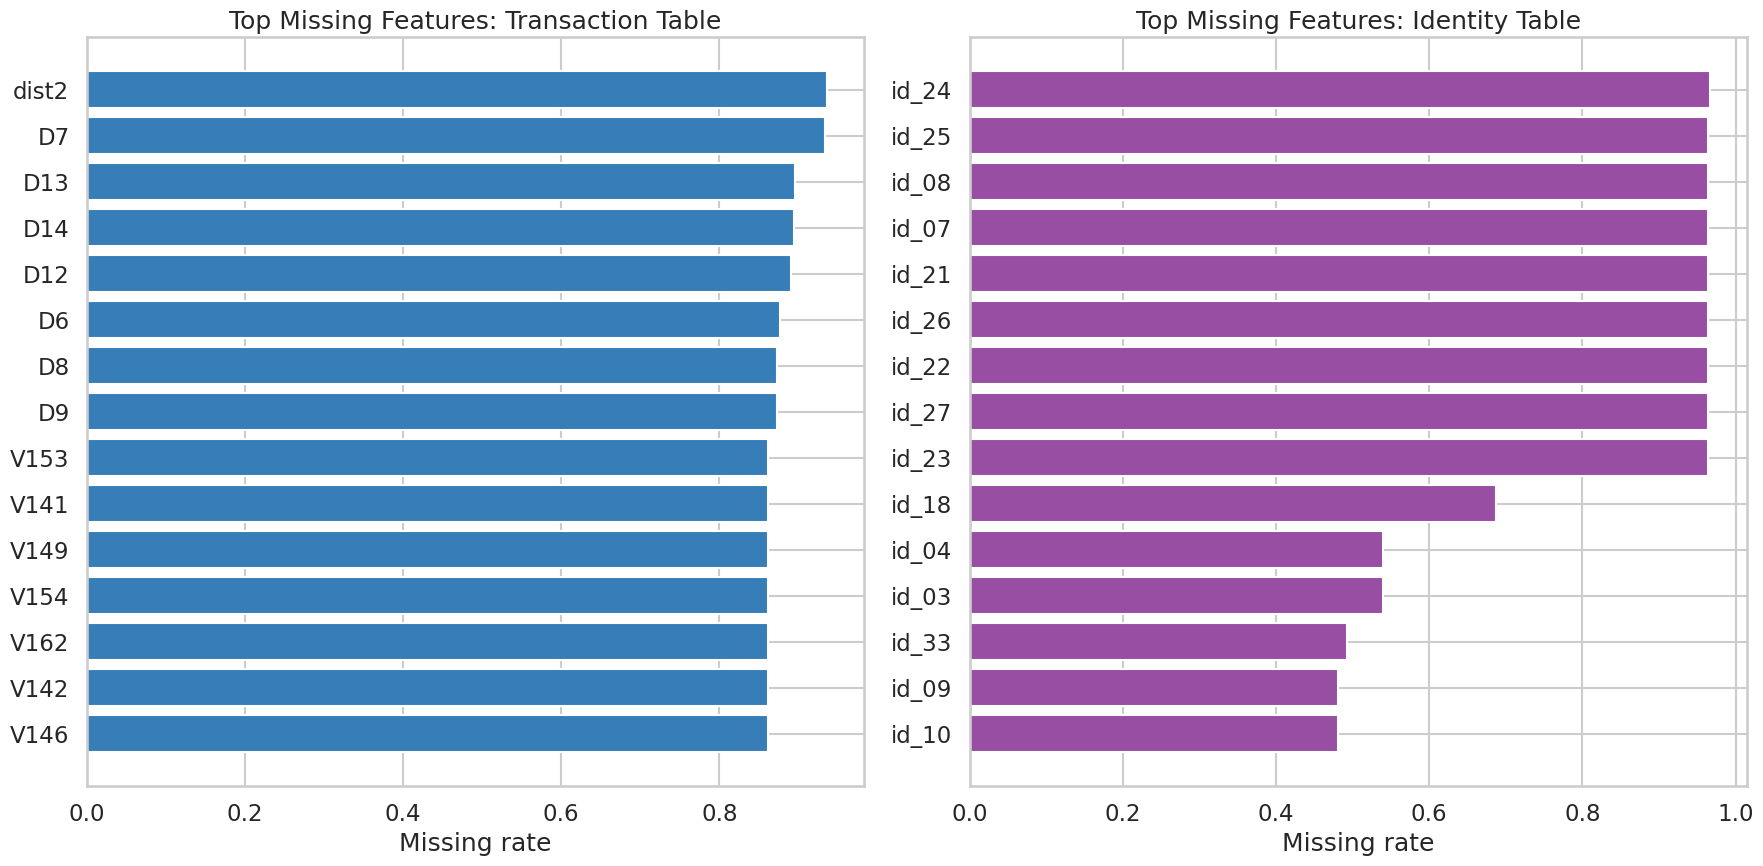

In [4]:
missing_summary = pd.concat(
    [
        top_missing(train_transaction, "train_transaction", n=25),
        top_missing(train_identity, "train_identity", n=25),
    ],
    ignore_index=True,
)
display(missing_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

tx_missing = top_missing(train_transaction, "train_transaction", n=15).sort_values("missing_rate")
axes[0].barh(tx_missing["feature"], tx_missing["missing_rate"], color="#377eb8")
axes[0].set_title("Top Missing Features: Transaction Table")
axes[0].set_xlabel("Missing rate")

id_missing = top_missing(train_identity, "train_identity", n=15).sort_values("missing_rate")
axes[1].barh(id_missing["feature"], id_missing["missing_rate"], color="#984ea3")
axes[1].set_title("Top Missing Features: Identity Table")
axes[1].set_xlabel("Missing rate")

plt.tight_layout()
plt.show()


## Transaction Amount and Time Patterns

`TransactionDT` is a relative time delta, so we treat it as an ordering variable rather than a real timestamp. For EDA, we derive approximate hours and days since the hidden reference point.


,count,mean,std,min,25%,50%,75%,max
TransactionAmt,"590,540.0000",135.0272,239.1625,0.2510,43.3210,68.7690,125.0000,"31,937.3910"
LogTransactionAmt,"590,540.0000",4.3830,0.9372,0.2239,3.7915,4.2452,4.8363,10.3716
TransactionDT,"590,540.0000","7,372,311.3101","4,617,223.6465","86,400.0000","3,027,057.7500","7,306,527.5000","11,246,620.0000","15,811,131.0000"
TransactionHour,"590,540.0000",13.8619,7.6072,0.0000,6.0000,16.0000,20.0000,23.0000
TransactionDay,"590,540.0000",84.7292,53.4373,1.0000,35.0000,84.0000,130.0000,182.0000


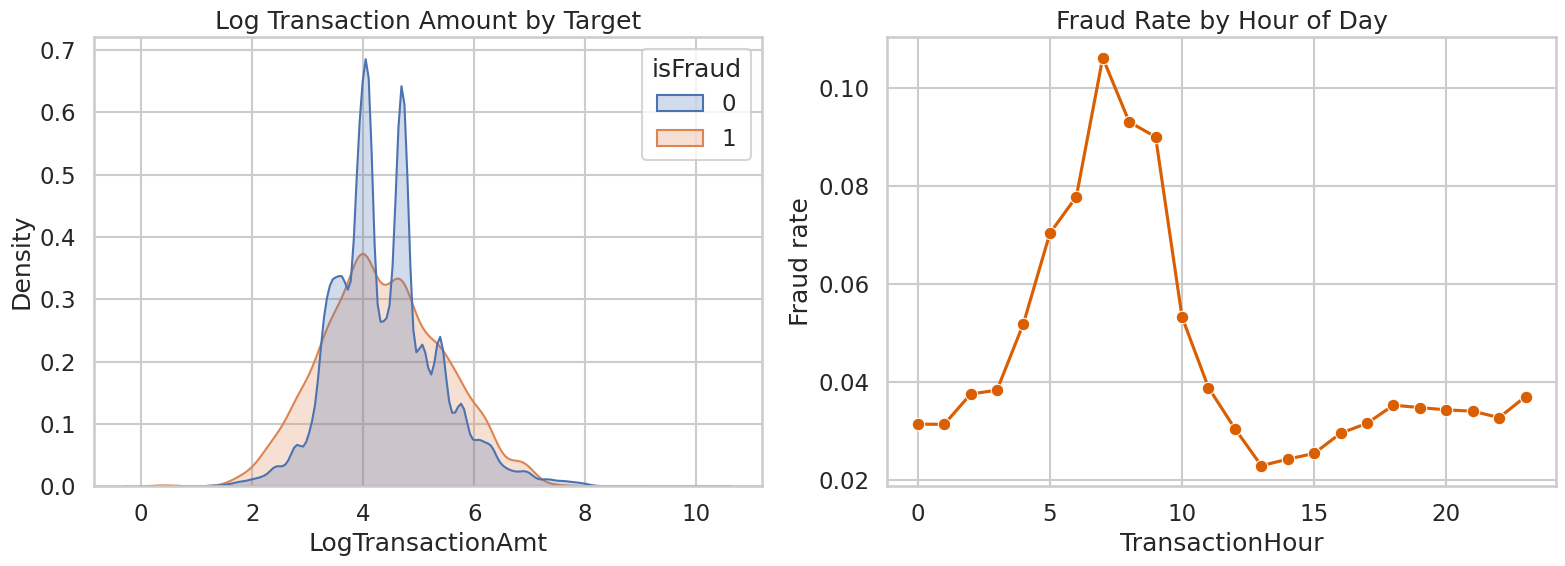

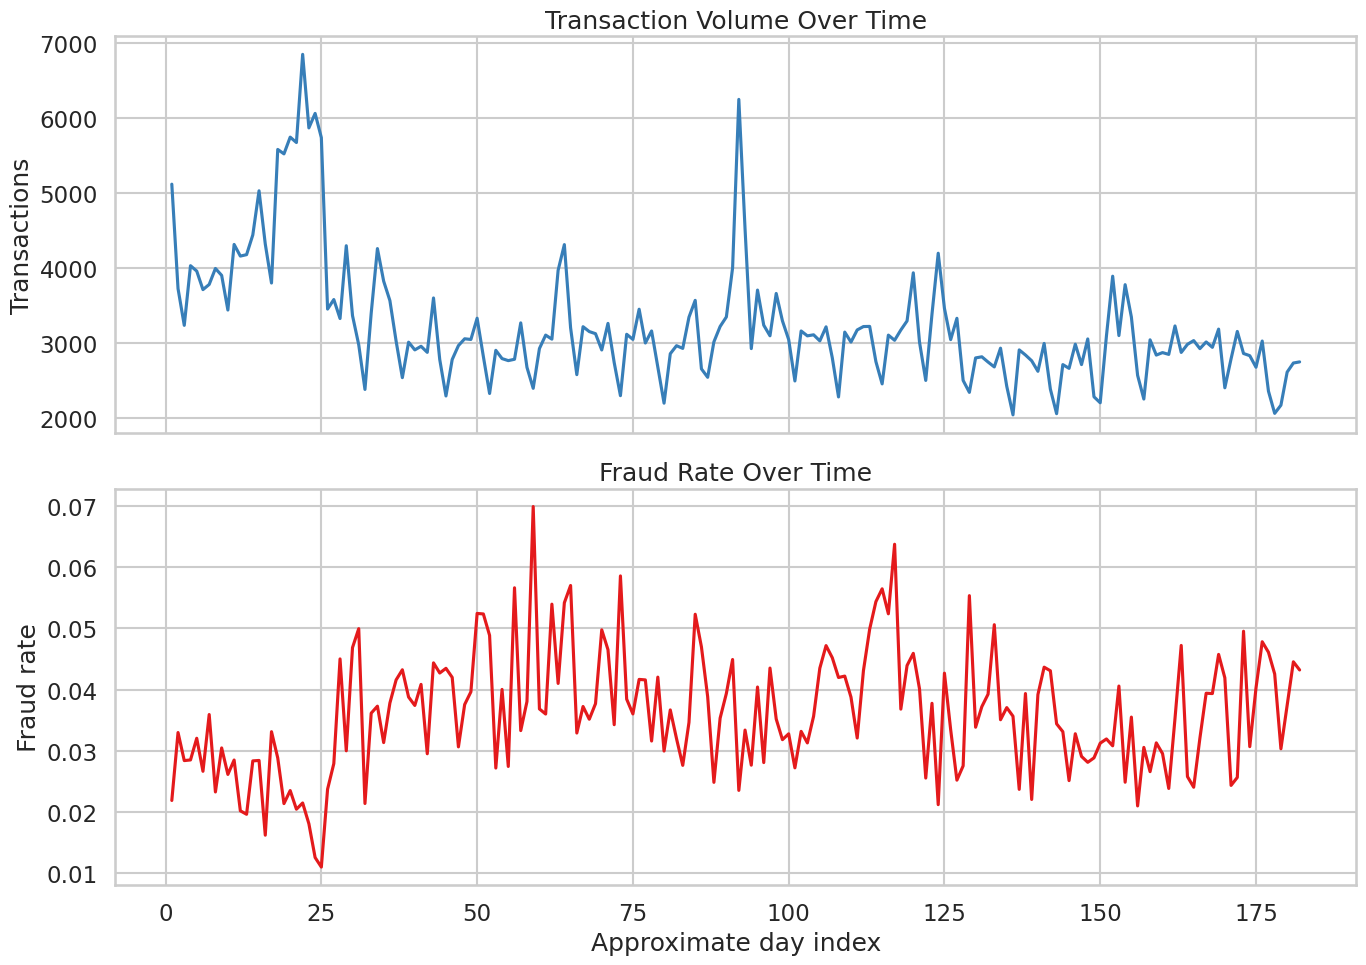

In [5]:
time_df = train_transaction[["TransactionDT", "TransactionAmt", "isFraud"]].copy()
time_df["TransactionHour"] = (time_df["TransactionDT"] // 3600) % 24
time_df["TransactionDay"] = time_df["TransactionDT"] // (3600 * 24)
time_df["LogTransactionAmt"] = np.log1p(time_df["TransactionAmt"])

display(
    time_df[["TransactionAmt", "LogTransactionAmt", "TransactionDT", "TransactionHour", "TransactionDay"]]
    .describe()
    .T
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(
    data=time_df.sample(min(len(time_df), 120000), random_state=RANDOM_STATE),
    x="LogTransactionAmt",
    hue="isFraud",
    common_norm=False,
    fill=True,
    ax=axes[0],
)
axes[0].set_title("Log Transaction Amount by Target")

hourly = (
    time_df.groupby("TransactionHour")
    .agg(transactions=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
    .reset_index()
)
sns.lineplot(data=hourly, x="TransactionHour", y="fraud_rate", marker="o", color="#d95f02", ax=axes[1])
axes[1].set_title("Fraud Rate by Hour of Day")
axes[1].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()

daily = (
    time_df.groupby("TransactionDay")
    .agg(transactions=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.lineplot(data=daily, x="TransactionDay", y="transactions", color="#377eb8", ax=axes[0])
axes[0].set_title("Transaction Volume Over Time")
axes[0].set_ylabel("Transactions")

sns.lineplot(data=daily, x="TransactionDay", y="fraud_rate", color="#e41a1c", ax=axes[1])
axes[1].set_title("Fraud Rate Over Time")
axes[1].set_ylabel("Fraud rate")
axes[1].set_xlabel("Approximate day index")

plt.tight_layout()
plt.show()


## Categorical Fraud Patterns

The dataset contains many masked categorical columns. We start with business-readable fields such as product, card network, email domain, and selected match variables.



Fraud profile for ProductCD


,transactions,fraud_rate
ProductCD,,
C,68519,0.1169
S,11628,0.0590
H,33024,0.0477
R,37699,0.0378
W,439670,0.0204


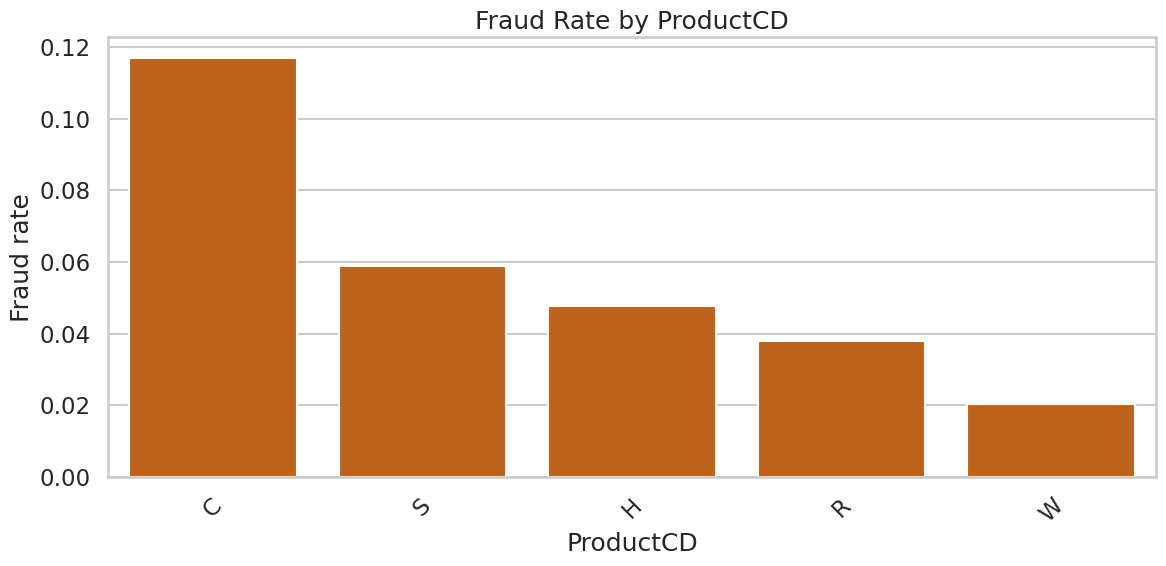


Fraud profile for card4


,transactions,fraud_rate
card4,,
discover,6651,0.0773
visa,384767,0.0348
mastercard,189217,0.0343
american express,8328,0.0287
NaN,1577,0.0260


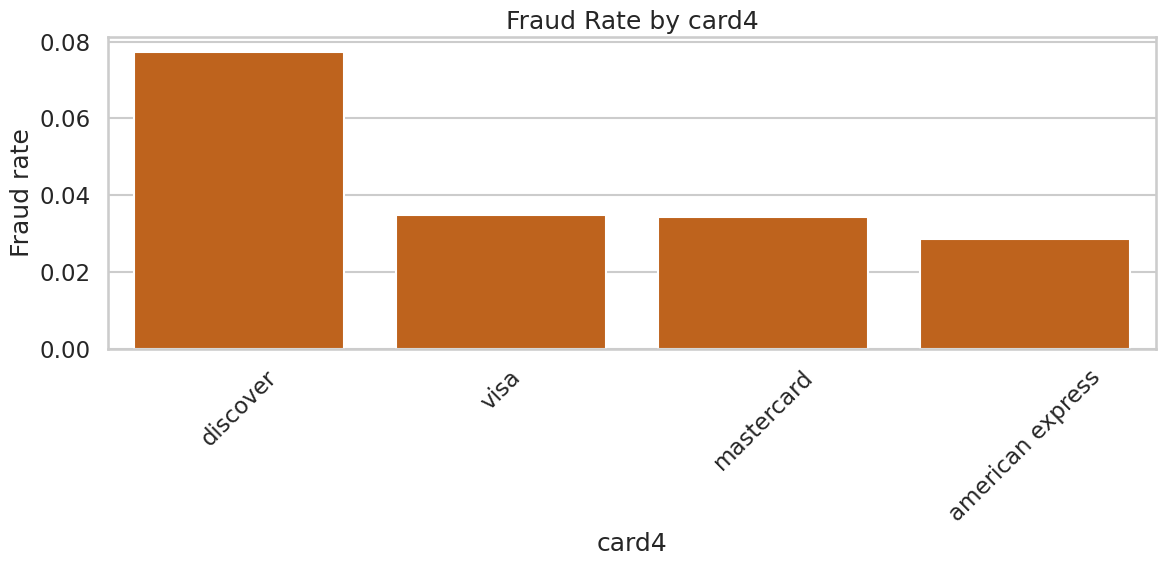


Fraud profile for card6


,transactions,fraud_rate
card6,,
credit,148986,0.0668
NaN,1571,0.0248
debit,439938,0.0243
charge card,15,0.0000
debit or credit,30,0.0000


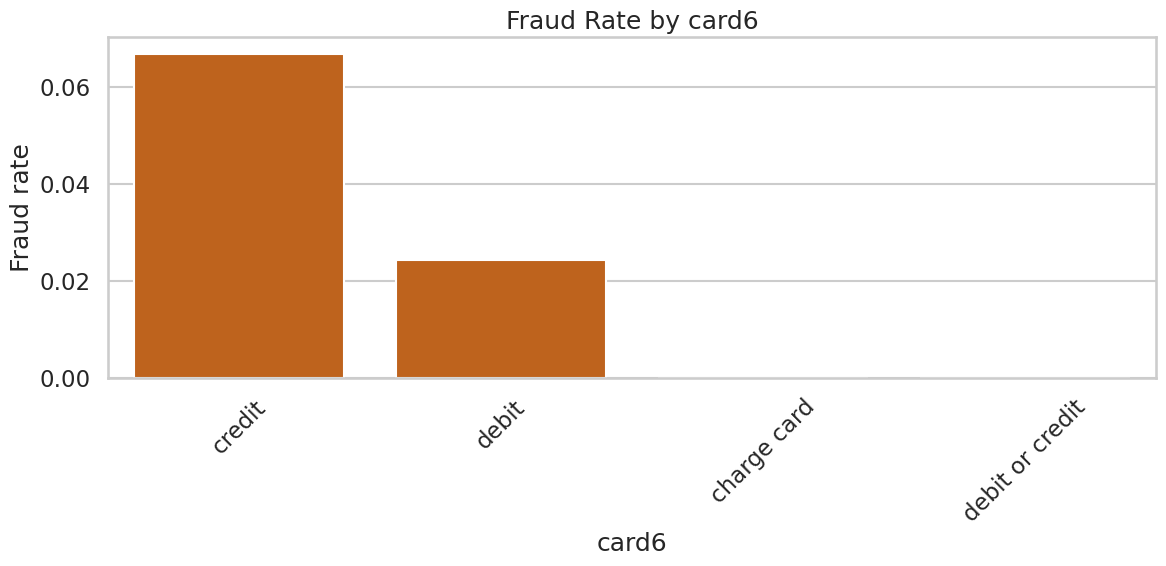


Fraud profile for P_emaildomain


,transactions,fraud_rate
P_emaildomain,,
outlook.com,5096,0.0946
hotmail.com,45250,0.0530
gmail.com,228355,0.0435
icloud.com,6267,0.0314
comcast.net,7888,0.0312
NaN,94456,0.0295
anonymous.com,36998,0.0232
yahoo.com,100934,0.0228
Other,32915,0.0227


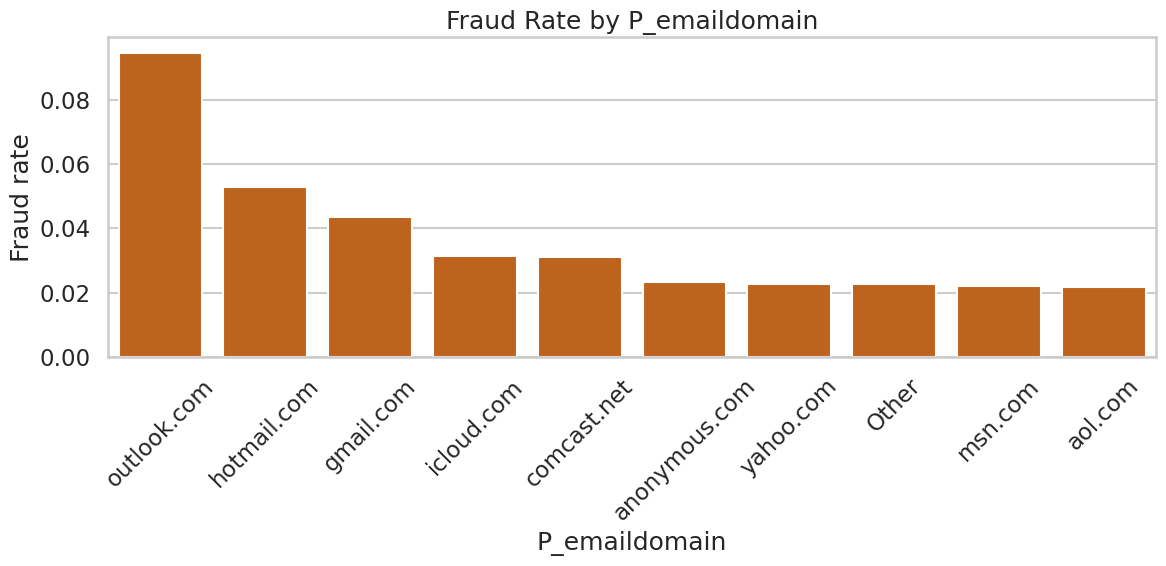


Fraud profile for R_emaildomain


,transactions,fraud_rate
R_emaildomain,,
outlook.com,2507,0.1651
icloud.com,1398,0.1288
gmail.com,57147,0.1192
hotmail.com,27509,0.0778
yahoo.com,11842,0.0515
aol.com,3701,0.0349
Other,9338,0.0330
anonymous.com,20529,0.0291
NaN,453249,0.0208


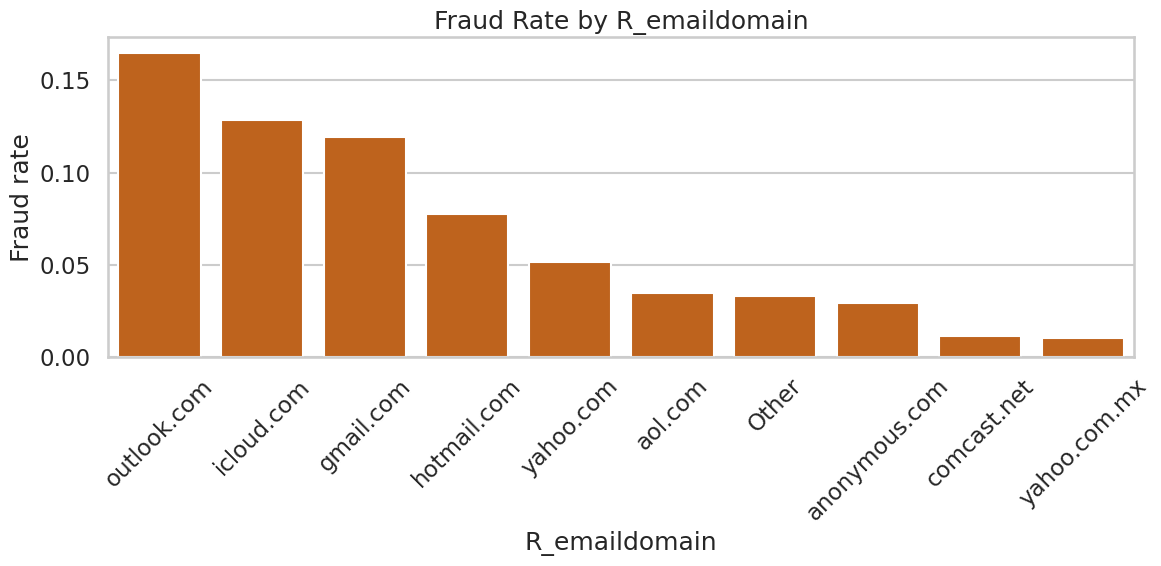


Fraud profile for M4


,transactions,fraud_rate
M4,,
M2,59865,0.1137
M0,196405,0.0366
M1,52826,0.0271
NaN,281444,0.0186


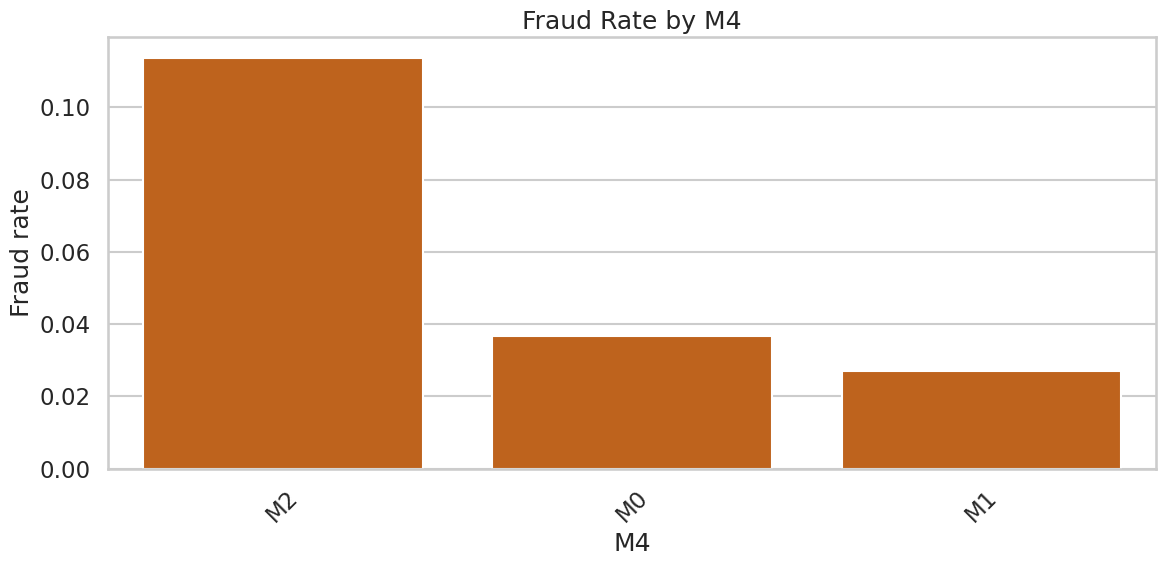

In [6]:
categorical_features = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "M4"]

for feature in categorical_features:
    summary = fraud_rate_table(train_transaction, feature, top_n=10)
    print(f"\nFraud profile for {feature}")
    display(summary)
    plot_fraud_rate(summary, f"Fraud Rate by {feature}", feature)


## Identity and Device Signals

Identity information is only available for a subset of transactions, but these fields often capture browser, OS, and device traits that are useful for fraud detection.


,transactions,fraud_rate
has_identity,,
False,449730,0.0210
True,140810,0.0796



Fraud profile for DeviceType


,transactions,fraud_rate
DeviceType,,
mobile,55645,0.1017
desktop,85165,0.0652
NaN,449730,0.0210


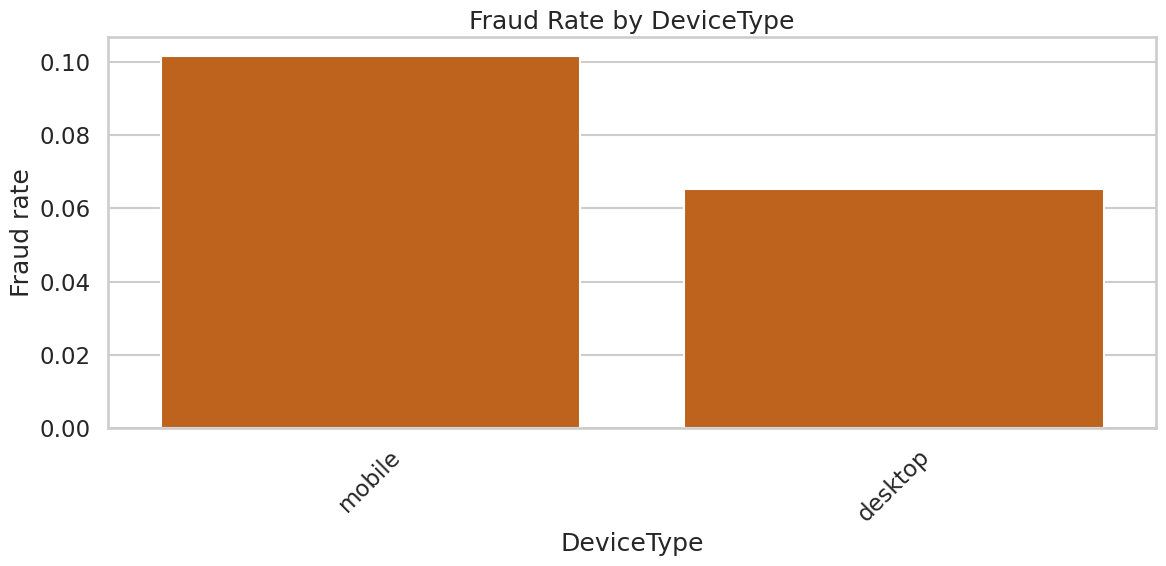


Fraud profile for DeviceInfo


,transactions,fraud_rate
DeviceInfo,,
Other,26504,0.1328
rv:59.0,362,0.1215
SM-J700M Build/MMB29K,549,0.1093
rv:57.0,962,0.1071
SM-G531H Build/LMY48B,410,0.0805
SM-G610M Build/MMB29K,461,0.0803
Windows,47722,0.0654
iOS Device,19782,0.0627
rv:11.0,1901,0.0400


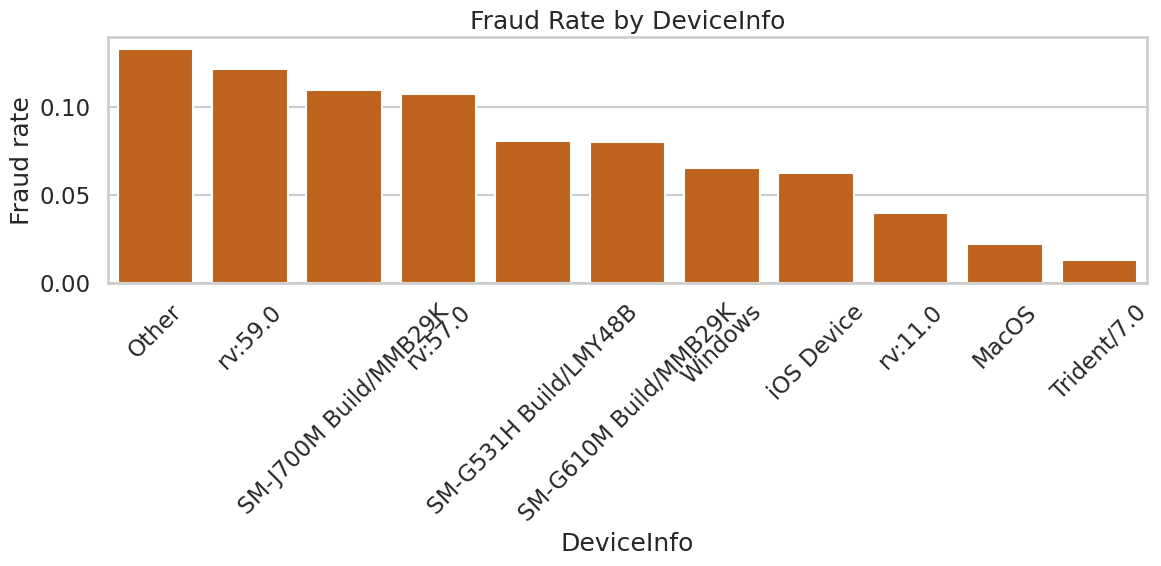


Fraud profile for id_30


,transactions,fraud_rate
id_30,,
Windows 8.1,1914,0.0695
iOS 11.3.0,2016,0.0685
Other,22520,0.0665
Android 7.0,2871,0.0578
iOS 11.2.1,3722,0.0492
iOS 11.1.2,3699,0.0351
NaN,512975,0.0336
Windows 7,13110,0.0330
Windows 10,21155,0.0311


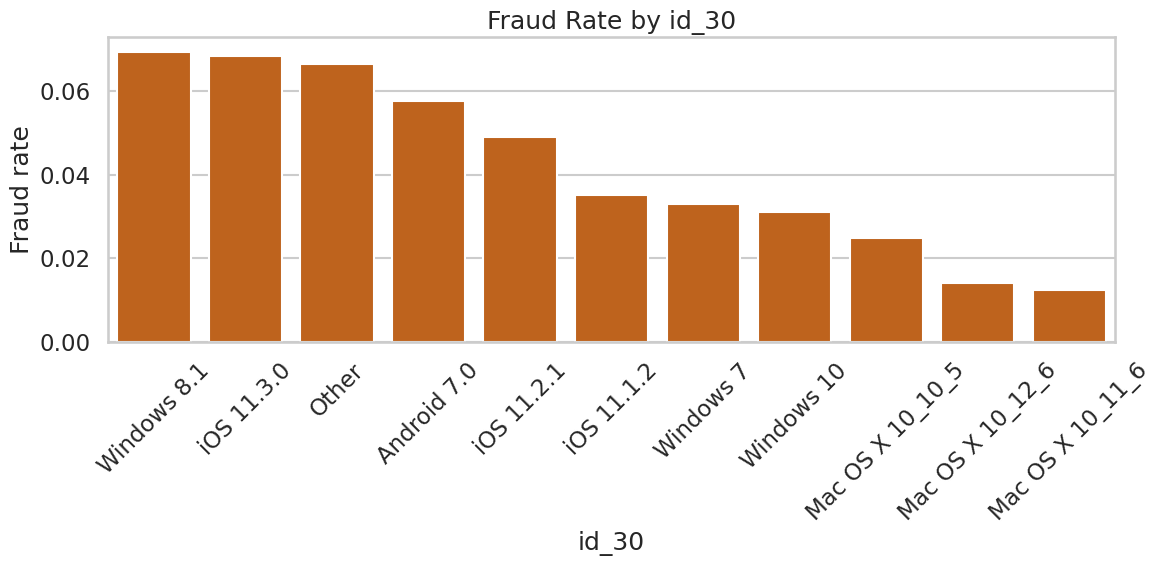


Fraud profile for id_31


,transactions,fraud_rate
id_31,,
chrome generic,4778,0.1681
chrome 63.0 for android,5806,0.1125
mobile safari generic,11474,0.0999
chrome 65.0,6871,0.0988
chrome 66.0,4264,0.0933
chrome 64.0,6711,0.0916
Other,44499,0.0899
chrome 63.0,22000,0.0683
mobile safari 11.0,13423,0.0627


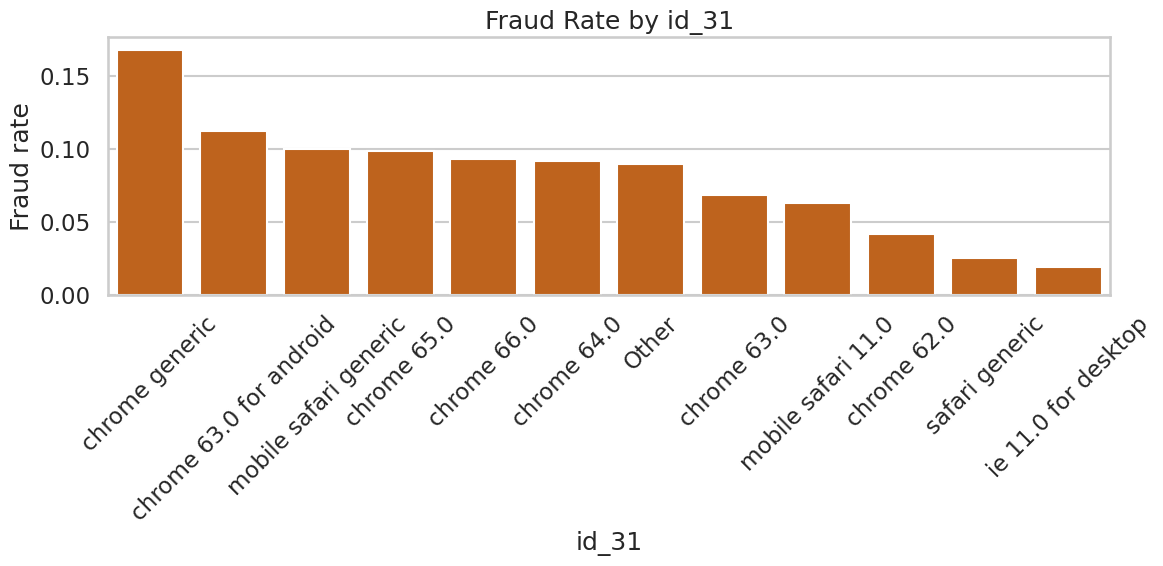


Fraud profile for id_33


,transactions,fraud_rate
id_33,,
2208x1242,4900,0.0984
1334x750,6447,0.0591
1366x768,8605,0.0573
Other,18980,0.0554
1280x800,2149,0.0479
NaN,517251,0.0334
1600x900,3510,0.0322
1440x900,4384,0.0292
1920x1080,16874,0.0290


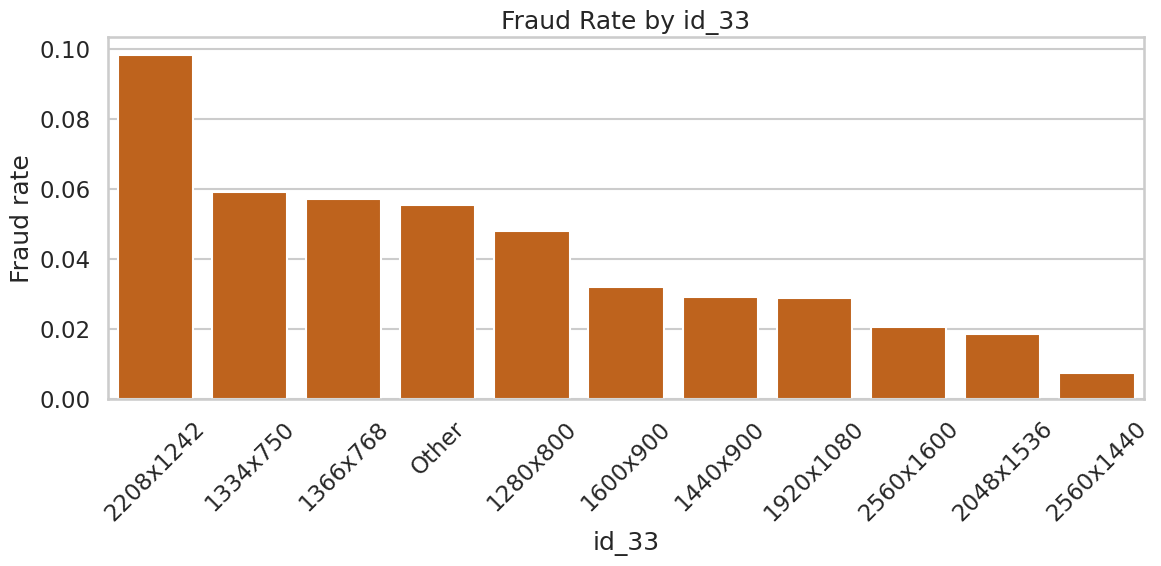

In [7]:
identity_analysis = train_transaction[
    ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt"]
].merge(train_identity, on="TransactionID", how="left")

identity_analysis["has_identity"] = identity_analysis["DeviceType"].notna()

identity_presence = (
    identity_analysis.groupby("has_identity")["isFraud"]
    .agg(["size", "mean"])
    .rename(columns={"size": "transactions", "mean": "fraud_rate"})
)
display(identity_presence)

for feature in ["DeviceType", "DeviceInfo", "id_30", "id_31", "id_33"]:
    summary = fraud_rate_table(identity_analysis, feature, top_n=12)
    print(f"\nFraud profile for {feature}")
    display(summary)
    plot_fraud_rate(summary, f"Fraud Rate by {feature}", feature)


## Predictive Baseline

To keep the notebook practical, we fit a lightweight gradient-boosting baseline on a curated subset of transaction and identity variables. We use a chronological split based on `TransactionDT`, which is more realistic than a random split for fraud problems with evolving behavior.


In [8]:
feature_columns = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "P_emaildomain",
    "R_emaildomain",
    "C1",
    "C2",
    "C5",
    "C11",
    "C12",
    "C14",
    "D1",
    "D2",
    "D3",
    "D4",
    "D10",
    "D11",
    "D15",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
]

identity_columns = [
    "TransactionID",
    "DeviceType",
    "DeviceInfo",
    "id_12",
    "id_15",
    "id_16",
    "id_28",
    "id_29",
    "id_30",
    "id_31",
    "id_33",
    "id_36",
    "id_37",
    "id_38",
]

model_df = train_transaction[feature_columns].merge(
    train_identity[identity_columns], on="TransactionID", how="left"
)

model_df["TransactionHour"] = (model_df["TransactionDT"] // 3600) % 24
model_df["TransactionDay"] = model_df["TransactionDT"] // (3600 * 24)
model_df["LogTransactionAmt"] = np.log1p(model_df["TransactionAmt"])

model_df = model_df.sort_values("TransactionDT").reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
valid_df = model_df.iloc[split_idx:].copy()

target = "isFraud"
drop_columns = ["TransactionID", "isFraud"]
feature_df = model_df.drop(columns=drop_columns)

categorical_cols = feature_df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [col for col in feature_df.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            encoded_missing_value=-1,
                        ),
                    ),
                ]
            ),
            categorical_cols,
        ),
    ]
)

model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_depth=6,
    max_iter=250,
    min_samples_leaf=80,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]
X_valid = valid_df.drop(columns=drop_columns)
y_valid = valid_df[target]

pipeline.fit(X_train, y_train)
valid_pred = pipeline.predict_proba(X_valid)[:, 1]

metrics = pd.DataFrame(
    {
        "metric": ["ROC AUC", "Average precision", "Validation fraud rate"],
        "value": [
            roc_auc_score(y_valid, valid_pred),
            average_precision_score(y_valid, valid_pred),
            y_valid.mean(),
        ],
    }
)
display(metrics)

top_k = max(1, int(len(y_valid) * 0.05))
top_precision = y_valid.iloc[np.argsort(-valid_pred)[:top_k]].mean()
lift = top_precision / y_valid.mean()
print(f"Precision within top 5% highest-risk validation transactions: {top_precision:.2%}")
print(f"Lift over base fraud rate: {lift:.2f}x")


,metric,value
0,ROC AUC,0.9001
1,Average precision,0.4988
2,Validation fraud rate,0.0344


Precision within top 5% highest-risk validation transactions: 38.97%
Lift over base fraud rate: 11.32x


,feature,importance_mean,importance_std
15,C1,0.2355,0.0106
20,C14,0.2149,0.0099
18,C11,0.0936,0.0060
17,C5,0.0546,0.0139
16,C2,0.0458,0.0090
2,ProductCD,0.0423,0.0077
1,TransactionAmt,0.0409,0.0107
3,card1,0.0373,0.0067
9,addr1,0.0279,0.0039
11,dist1,0.0261,0.0032


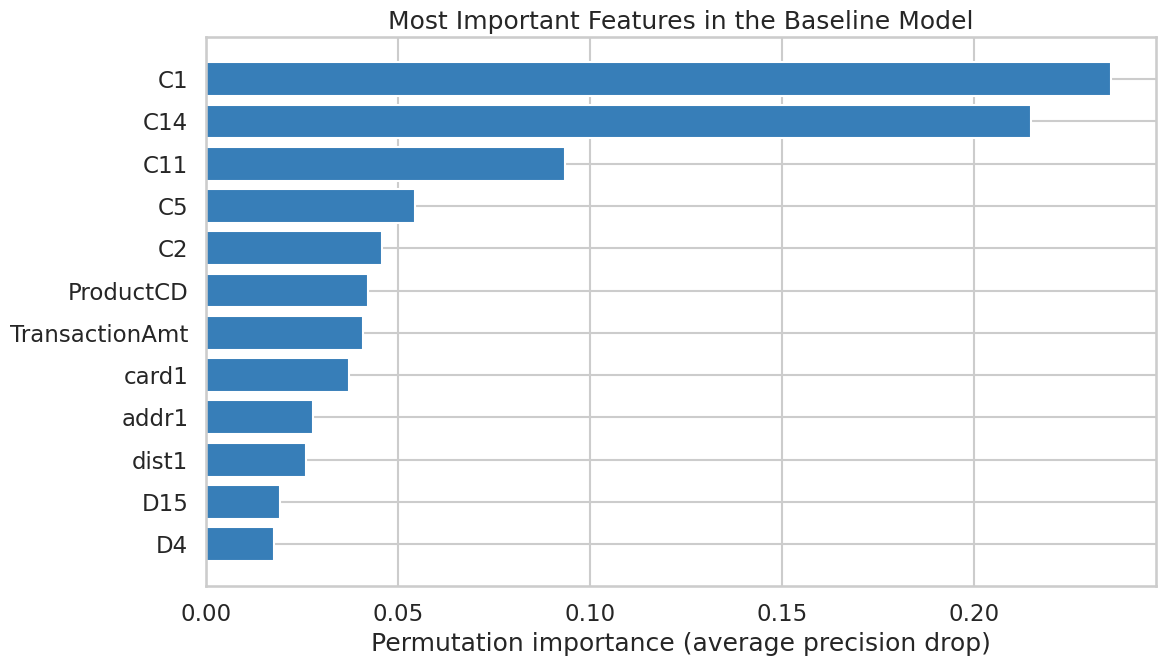

In [9]:
sample_size = min(5000, len(X_valid))
sample_idx = np.linspace(0, len(X_valid) - 1, sample_size, dtype=int)
X_valid_sample = X_valid.iloc[sample_idx]
y_valid_sample = y_valid.iloc[sample_idx]

perm = permutation_importance(
    pipeline,
    X_valid_sample,
    y_valid_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="average_precision",
)

importance = pd.DataFrame(
    {
        "feature": X_valid.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(importance.head(15))

top_importance = importance.head(12).sort_values("importance_mean")
plt.figure(figsize=(12, 7))
plt.barh(top_importance["feature"], top_importance["importance_mean"], color="#377eb8")
plt.xlabel("Permutation importance (average precision drop)")
plt.title("Most Important Features in the Baseline Model")
plt.tight_layout()
plt.show()


In [10]:
key_findings = pd.DataFrame(
    {
        "finding": [
            "The training set is heavily imbalanced, so precision-recall metrics are more informative than accuracy.",
            "Only a minority of transactions include identity data, but those fields still contain meaningful fraud signal.",
            "Missingness is extensive across engineered features, suggesting that null patterns themselves may be predictive.",
            "Fraud patterns vary over the relative transaction timeline, so time-aware validation is appropriate.",
            "A compact baseline already separates fraud substantially better than the raw base rate, indicating the prediction task is learnable.",
        ]
    }
)
display(key_findings)


,finding
0,"The training set is heavily imbalanced, so pre..."
1,Only a minority of transactions include identi...
2,Missingness is extensive across engineered fea...
3,Fraud patterns vary over the relative transact...
4,A compact baseline already separates fraud sub...
